In [23]:
import pandas as pd
import numpy as np


df = pd.read_csv("spambase_csv.csv")

In [2]:
df.head()
df.info()
df.describe()
df.columns
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

(4601, 58)

In [3]:
df.columns

Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',


In [5]:
print(df['class'].nunique())
df['class'].unique()

2


array([1, 0], dtype=int64)

In [7]:
df.isnull().sum()
df.fillna(df.mean(),inplace=True)

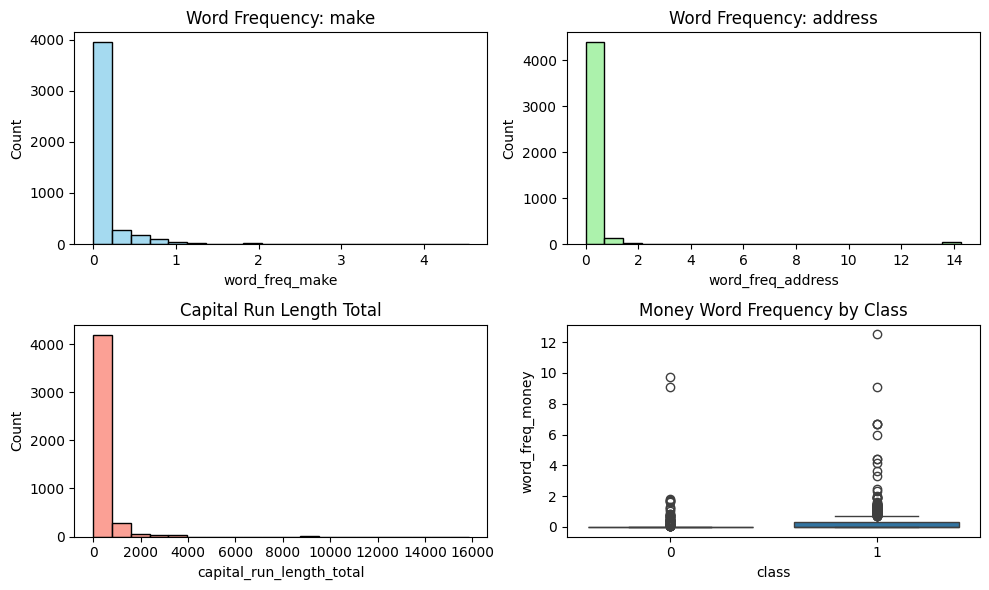

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(10, 6)
)

axes = axes.flatten()

sns.histplot(df, x='word_freq_make', bins=20, color='skyblue', ax=axes[0])
axes[0].set_title('Word Frequency: make')

sns.histplot(df, x='word_freq_address', bins=20, color='lightgreen', ax=axes[1])
axes[1].set_title('Word Frequency: address')

sns.histplot(df, x='capital_run_length_total', bins=20, color='salmon', ax=axes[2])
axes[2].set_title('Capital Run Length Total')

sns.boxplot(data=df, x='class', y='word_freq_money', ax=axes[3])
axes[3].set_title('Money Word Frequency by Class')

plt.tight_layout()
plt.show()


(array([2788.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1813.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

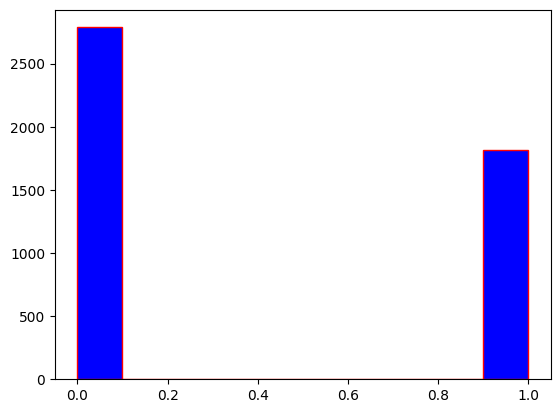

In [15]:
plt.hist(
df['class'], bins=10,
color='blue', edgecolor="red"
)

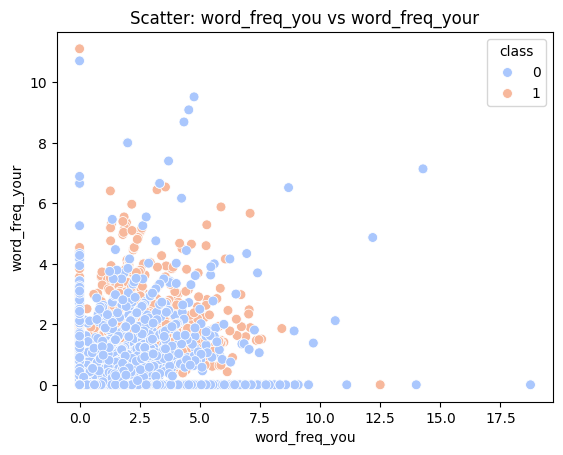

In [16]:
sns.scatterplot(
    x=df['word_freq_you'], 
    y=df['word_freq_your'],
    hue=df['class'],
    palette='coolwarm',
    s=50
)
plt.title('Scatter: word_freq_you vs word_freq_your')
plt.show()


In [ ]:
plt.figure(figsize=(50,50))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

### Scaling

In [24]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler, RobustScaler

X_std = StandardScaler().fit_transform(df.drop(columns=['class'],inplace=False))
y=df['class']

### Encoding

In [25]:
from sklearn.preprocessing import LabelBinarizer
lb = LabelBinarizer(
neg_label=0, pos_label=1, sparse_output=False
)
y_bin = lb.fit_transform(y)
y_inv = lb.inverse_transform(y_bin)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore')
X_oh = ohe.fit_transform(df[['City']]).toarray()

# Add to DataFrame
oh_df = pd.DataFrame(X_oh, columns=ohe.get_feature_names_out(['City']))
df_encoded = pd.concat([df, oh_df], axis=1)
print(df_encoded)


### Train-Test Split

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X_std, y, test_size=0.3, random_state=42, stratify=y
)

In [29]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso,LogisticRegression

log=LogisticRegression(
penalty="l2",
C=1.0,
solver="liblinear",
random_state=42
)

log.fit(X_train,y_train)
y_pred=log.predict(X_test)

print(log.score(X_test,y_test))

0.9283128167994207


4538    0
2208    0
1685    0
778     0
1241    0
       ..
660     0
4421    0
3381    0
558     0
2538    0
Name: class, Length: 1381, dtype: int64


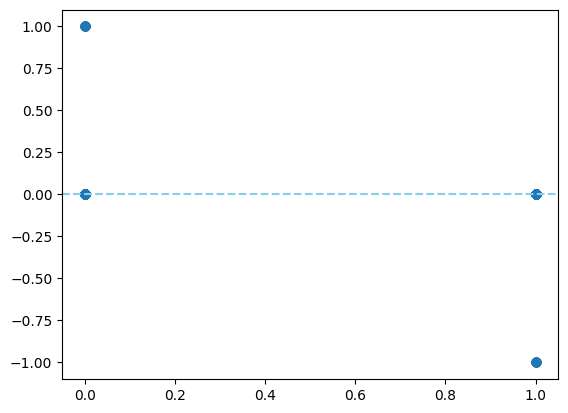

In [31]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color="skyblue", linestyle="--")

print(residuals)

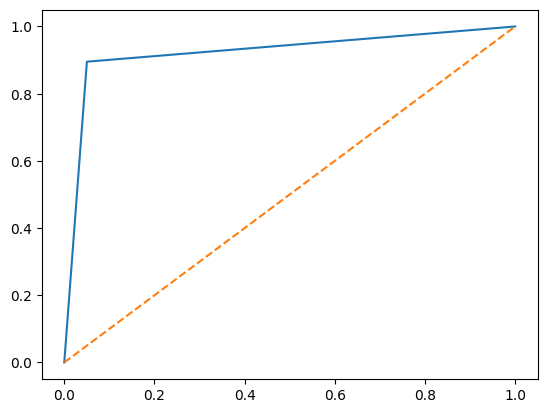

In [33]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thr = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr); 
plt.plot([0,1],[0,1], linestyle="--")